# **Lot 3 — Modélisation**
### **Projet NLP · Analyse de sentiment des tweets de compagnies aériennes**

Progression **du plus simple au plus avancé**, en croisant **représentations × architectures**
(le cœur de l'évaluation). Tout repose sur le **split figé** et les **représentations** des Lots 1-2.

| Architecture | Représentation | Rôle |
|---|---|---|
| Régression logistique | TF-IDF / W2V / BERT | référence (Lot 2) |
| **ANN** | TF-IDF, Word2Vec, BERT | réseau dense |
| **CNN 1D** | Word2Vec | détection de n-grammes |
| **LSTM (BiLSTM)** | Word2Vec | dépendance séquentielle |
| **Attention (BiLSTM+Attn)** | Word2Vec | pondération des mots (interprétable) |
| **Fine-tuning** | DistilBERT | contextuel, état de l'art |

> Métrique : **F1-macro**. Sélection du meilleur modèle sur la **validation**, **test réservé** au Lot 4.

In [1]:
import sys, json, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from sklearn.metrics import f1_score

def find_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base/"data"/"Tweets.csv").exists(): return base
    return Path.cwd()
ROOT=find_root(); SRC=ROOT/"delivarables"/"src"; OUT=ROOT/"delivarables"/"data_processed"
ART=ROOT/"delivarables"/"artifacts"; FIG=ROOT/"delivarables"/"figures"
sys.path.insert(0,str(SRC))
import dl_models as M, seq_utils as S, viz_style as vz
vz.apply_theme(); M.set_seed(42)

train=pd.read_csv(OUT/"train.csv"); val=pd.read_csv(OUT/"val.csv"); test=pd.read_csv(OUT/"test.csv")
for d in (train,val,test): d["text_clean"]=d["text_clean"].fillna("")
meta=json.loads((OUT/"meta.json").read_text())
ORDER=["negative","neutral","positive"]; cw=[meta["class_weight"][c] for c in ORDER]
ytr,yva,yte=train["label"].values,val["label"].values,test["label"].values
print("class_weight:",cw)

results={}   # nom -> {arch, repr, val_f1, test_f1, dim}
from torch.utils.data import DataLoader
def record(name, arch, rep, model, val_ds, test_ds, history=None):
    vf,_=M.evaluate(model, DataLoader(val_ds,256))
    tf,ptest=M.evaluate(model, DataLoader(test_ds,256))
    results[name]={"arch":arch,"repr":rep,"val_f1":round(float(vf),4),"test_f1":round(float(tf),4)}
    np.save(ART/f"pred_test_{name}.npy", ptest)
    if history is not None: json.dump(history, open(ART/f"history_{name}.json","w"))
    print(f"{name:18} val_F1={vf:.4f}  test_F1={tf:.4f}")

class_weight: [0.532, 1.575, 2.065]


## **1. Référence — ANN sur TF-IDF**
Réseau dense (256→128→3) sur les vecteurs TF-IDF. C'est notre référence profonde.

In [2]:
Xtr=sp.load_npz(ART/"tfidf_train.npz"); Xva=sp.load_npz(ART/"tfidf_val.npz"); Xte=sp.load_npz(ART/"tfidf_test.npz")
dtr=M.DenseDataset(Xtr,ytr); dva=M.DenseDataset(Xva,yva); dte=M.DenseDataset(Xte,yte)
ann=M.ANN(Xtr.shape[1], hidden=256)
h,_=M.fit(ann,dtr,dva,cw,epochs=12,lr=1e-3,batch_size=64)
record("ANN-TFIDF","ANN","TF-IDF",ann,dva,dte,h)

  epoch  1/12  loss=0.8239  val_F1=0.7385


  epoch  2/12  loss=0.3781  val_F1=0.7549


  epoch  3/12  loss=0.1856  val_F1=0.7633


  epoch  4/12  loss=0.0992  val_F1=0.7443


  epoch  5/12  loss=0.0608  val_F1=0.7500


...

  epoch  9/12  loss=0.0294  val_F1=0.7321


  epoch 10/12  loss=0.0312  val_F1=0.7318


  epoch 11/12  loss=0.0275  val_F1=0.7361


  epoch 12/12  loss=0.0307  val_F1=0.7327


ANN-TFIDF          val_F1=0.7633  test_F1=0.7407


## **2. ANN sur embeddings denses (BERT & Word2Vec)**
On applique le même réseau dense aux embeddings **BERT** (768-d) et aux **vecteurs de document Word2Vec** (100-d).

In [3]:
# BERT features
Btr=np.load(ART/"bert_train.npy"); Bva=np.load(ART/"bert_val.npy"); Bte=np.load(ART/"bert_test.npy")
annB=M.ANN(768, hidden=256)
h,_=M.fit(annB, M.DenseDataset(Btr,ytr), M.DenseDataset(Bva,yva), cw, epochs=15, lr=1e-3)
record("ANN-BERT","ANN","BERT",annB, M.DenseDataset(Bva,yva), M.DenseDataset(Bte,yte), h)

# Word2Vec doc vectors
Wtr=np.load(ART/"w2v_doc_train.npy"); Wva=np.load(ART/"w2v_doc_val.npy"); Wte=np.load(ART/"w2v_doc_test.npy")
annW=M.ANN(Wtr.shape[1], hidden=128)
h,_=M.fit(annW, M.DenseDataset(Wtr,ytr), M.DenseDataset(Wva,yva), cw, epochs=15, lr=1e-3)
record("ANN-W2V","ANN","Word2Vec",annW, M.DenseDataset(Wva,yva), M.DenseDataset(Wte,yte), h)

  epoch  1/15  loss=0.7456  val_F1=0.7306


  epoch  2/15  loss=0.6064  val_F1=0.7530


  epoch  3/15  loss=0.5822  val_F1=0.7394


  epoch  4/15  loss=0.5664  val_F1=0.7414


  epoch  5/15  loss=0.5561  val_F1=0.7313


...

  epoch 11/15  loss=0.6326  val_F1=0.7067


  epoch 12/15  loss=0.6195  val_F1=0.7126


  epoch 13/15  loss=0.6134  val_F1=0.7161


  epoch 14/15  loss=0.6103  val_F1=0.7060


  epoch 15/15  loss=0.6071  val_F1=0.6967
ANN-W2V            val_F1=0.7161  test_F1=0.7026


## **3. Modèles séquentiels sur Word2Vec (CNN, LSTM, Attention)**
On construit des **séquences d'indices** (maxlen=40) et une **couche d'embedding initialisée par
notre Word2Vec** (affinable). C'est ici que Word2Vec révèle sa valeur.

In [4]:
emb,w2i,pad=S.load_w2v(ART)
Str=S.texts_to_sequences(train["text_clean"],w2i,pad,40)
Sva=S.texts_to_sequences(val["text_clean"],w2i,pad,40)
Ste=S.texts_to_sequences(test["text_clean"],w2i,pad,40)
sdtr=M.SeqDataset(Str,ytr); sdva=M.SeqDataset(Sva,yva); sdte=M.SeqDataset(Ste,yte)
print("séquences:",Str.shape,"| embedding:",emb.shape)

séquences: (10248, 40) | embedding: (3518, 100)


In [5]:
print("=== CNN ===")
cnn=M.TextCNN(emb,pad); h,_=M.fit(cnn,sdtr,sdva,cw,epochs=12,lr=1e-3); record("CNN-W2V","CNN","Word2Vec",cnn,sdva,sdte,h)
print("=== LSTM ===")
lstm=M.BiLSTM(emb,pad); h,_=M.fit(lstm,sdtr,sdva,cw,epochs=12,lr=1e-3); record("LSTM-W2V","LSTM","Word2Vec",lstm,sdva,sdte,h)
print("=== Attention ===")
attn=M.AttnBiLSTM(emb,pad); h,_=M.fit(attn,sdtr,sdva,cw,epochs=12,lr=1e-3); record("Attn-W2V","Attention","Word2Vec",attn,sdva,sdte,h)
import torch
torch.save(attn.state_dict(), ART/"attn_w2v_state.pt")   # reutilise pour l'interpretabilite (Lot 4)

=== CNN ===


  epoch  1/12  loss=0.8104  val_F1=0.7158


  epoch  2/12  loss=0.5690  val_F1=0.7357


  epoch  3/12  loss=0.4670  val_F1=0.7333


  epoch  4/12  loss=0.3683  val_F1=0.7380


...

  epoch  9/12  loss=0.2335  val_F1=0.7343


  epoch 10/12  loss=0.2069  val_F1=0.7231


  epoch 11/12  loss=0.1802  val_F1=0.7246


  epoch 12/12  loss=0.1529  val_F1=0.7216


Attn-W2V           val_F1=0.7572  test_F1=0.7342


## **4. Fine-tuning DistilBERT**
Le fine-tuning est entraîné **séparément** (`src/finetune_bert.py`, ~15-20 min CPU) et son résultat
est **chargé ici** pour ne pas bloquer le notebook.

In [6]:
ft_path = ART/"bert_finetune_results.json"
if ft_path.exists():
    ft=json.loads(ft_path.read_text())
    results["BERT-finetune"]={"arch":"Fine-tuning","repr":"BERT","val_f1":ft["val_f1"],"test_f1":ft["test_f1"]}
    print("BERT fine-tune charge :", results["BERT-finetune"])
else:
    print("⚠️ Resultat BERT fine-tune absent (lancer src/finetune_bert.py).")

BERT fine-tune charge : {'arch': 'Fine-tuning', 'repr': 'BERT', 'val_f1': 0.7979, 'test_f1': 0.7616}


## **5. Matrice de comparaison — représentations × architectures**
La synthèse exigée par le sujet : *quel embedding apporte le plus, et pour quel modèle ?*

In [7]:
# Baselines LogReg du Lot 2
lot2=json.loads((ART/"lot2_representation_scores.json").read_text())
for rep,v in lot2.items(): results[f"LogReg-{rep}"]={"arch":"LogReg","repr":rep,"val_f1":v["f1_macro_val"],"test_f1":None}

df=pd.DataFrame(results).T
df["val_f1"]=df["val_f1"].astype(float)
matrix=df.pivot_table(index="arch", columns="repr", values="val_f1", aggfunc="max")
arch_order=["LogReg","ANN","CNN","LSTM","Attention","Fine-tuning"]
rep_order=["TF-IDF","Word2Vec","BERT"]
matrix=matrix.reindex(index=[a for a in arch_order if a in matrix.index], columns=rep_order)
print("F1-macro (validation) :"); print(matrix.round(3))
json.dump(results, open(ART/"lot3_results.json","w"), indent=2)

F1-macro (validation) :
repr         TF-IDF  Word2Vec   BERT
arch                                
LogReg        0.757     0.676  0.751
ANN           0.763     0.716  0.764
CNN             NaN     0.755    NaN
LSTM            NaN     0.758    NaN
Attention       NaN     0.757    NaN
Fine-tuning     NaN       NaN  0.798


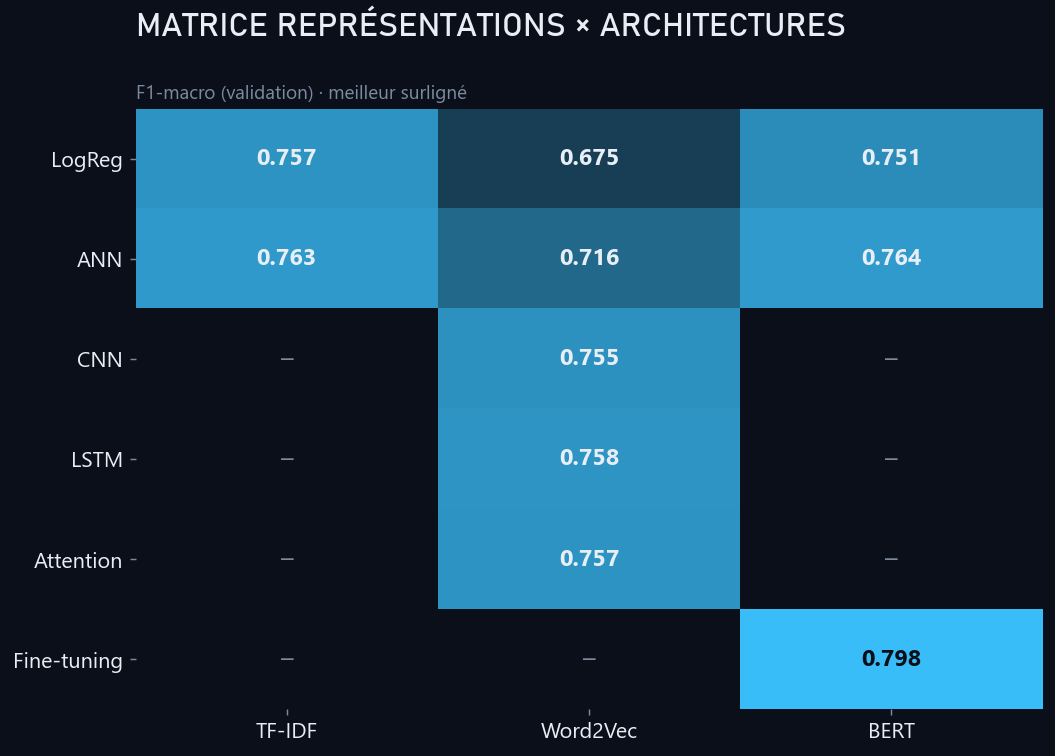

In [8]:
# Heatmap dashboard
mat=matrix.values.astype(float)
fig,ax=plt.subplots(figsize=(9,6))
cmap=vz._cmap("#10202E", vz.CYAN, "hm")
im=ax.imshow(np.ma.masked_invalid(mat), cmap=cmap, aspect="auto", vmin=np.nanmin(mat)-0.03, vmax=np.nanmax(mat))
ax.set_xticks(range(len(rep_order))); ax.set_xticklabels(rep_order, color=vz.TEXT, fontsize=12)
ax.set_yticks(range(matrix.shape[0])); ax.set_yticklabels(matrix.index, color=vz.TEXT, fontsize=12)
best=np.nanmax(mat)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v=mat[i,j]
        if not np.isnan(v):
            ax.text(j,i,f"{v:.3f}", ha="center", va="center", fontsize=13,
                    fontweight="bold", color=("#0B0F19" if v==best else vz.TEXT))
        else:
            ax.text(j,i,"–", ha="center", va="center", color=vz.MUTED, fontsize=14)
ax.grid(False)
vz.title(ax,"MATRICE REPRÉSENTATIONS × ARCHITECTURES","F1-macro (validation) · meilleur surligné", size=18)
vz.savefig(fig,FIG/"lot3_matrice.png"); plt.show()

### **Courbes d'apprentissage (F1-macro validation par époque)**

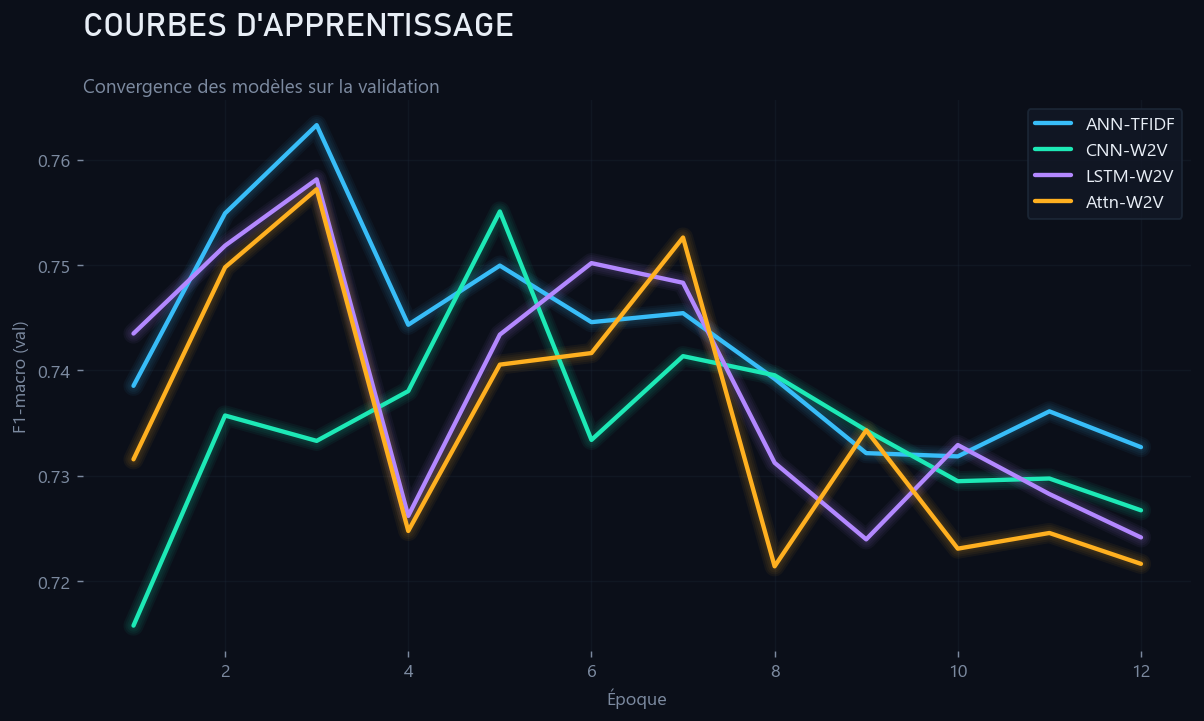

In [9]:
fig,ax=plt.subplots(figsize=(11,5.5))
palette={"ANN-TFIDF":vz.CYAN,"CNN-W2V":vz.POS,"LSTM-W2V":vz.PURPLE,"Attn-W2V":vz.AMBER}
for name,c in palette.items():
    p=ART/f"history_{name}.json"
    if p.exists():
        hh=json.loads(p.read_text())
        vz.glow_line(ax, range(1,len(hh["val_f1"])+1), hh["val_f1"], color=c, lw=2.4, n=4, base_alpha=0.05, label=name)
ax.legend(facecolor=vz.PANEL, edgecolor=vz.GRID, labelcolor=vz.TEXT, fontsize=10)
ax.set_xlabel("Époque", color=vz.MUTED); ax.set_ylabel("F1-macro (val)", color=vz.MUTED); ax.grid(alpha=0.3)
vz.title(ax,"COURBES D'APPRENTISSAGE","Convergence des modèles sur la validation", size=18)
vz.savefig(fig,FIG/"lot3_courbes.png"); plt.show()